# 1. Import and Hardware Setup

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageDraw, ImageFont
import os
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import glob
import json
from itertools import product

!pip install tqdm kagglehub -q
import kagglehub
from tqdm.auto import tqdm

# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


# 2. Hyperparameters

In [65]:
# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------

# Image settings
IMG_SIZE = 300             # SSD300 standard input resolution
IN_CHANNELS = 3            # RGB images
NUM_CLASSES = 21           # 20 Pascal VOC object classes + 1 background class

# Class names (index 0 = background)
CLASS_NAMES = [
    "background",     # 0
    "aeroplane",      # 1
    "bicycle",        # 2
    "bird",           # 3
    "boat",           # 4
    "bottle",         # 5
    "bus",            # 6
    "car",            # 7
    "cat",            # 8
    "chair",          # 9
    "cow",            # 10
    "diningtable",    # 11
    "dog",            # 12
    "horse",          # 13
    "motorbike",      # 14
    "person",         # 15
    "pottedplant",    # 16
    "sheep",          # 17
    "sofa",           # 18
    "train",          # 19
    "tvmonitor",      # 20
]

# Training settings
BATCH_SIZE = 16
LR = 1e-4                  # Initial learning rate for AdamW
EPOCHS = 100
SEED = 42
WEIGHT_DECAY = 5e-4

# SSD-specific settings
CONF_THRESHOLD = 0.5       # Confidence threshold for detection
NMS_THRESHOLD = 0.45       # Non-Maximum Suppression IoU threshold
NEG_POS_RATIO = 3          # Hard negative mining ratio
TOP_K_DETECTIONS = 200     # Max detections per image

# Early stopping patience
PATIENCE = 10


# 3. Dataset Download (Pascal VOC 2012 via kagglehub)

In [66]:
# Download Pascal VOC 2012 object detection dataset via kagglehub
DATASET_PATH = kagglehub.dataset_download("banuprasadb/pascal-voc-2012")
print(f"Dataset downloaded to: {DATASET_PATH}")

# Auto-detect the actual root (some kaggle downloads nest an extra folder)
def find_split_root(base_path):
    """Find the directory that directly contains train/ and val/ subfolders."""
    # Check if the splits are directly under base_path
    if all(os.path.isdir(os.path.join(base_path, s)) for s in ["train", "val"]):
        return base_path
    # Otherwise search one level deeper
    for entry in os.listdir(base_path):
        candidate = os.path.join(base_path, entry)
        if os.path.isdir(candidate):
            if all(os.path.isdir(os.path.join(candidate, s)) for s in ["train", "val"]):
                return candidate
    raise FileNotFoundError(f"Could not find train/val directories under {base_path}")

DATA_ROOT = find_split_root(DATASET_PATH)
print(f"Data root: {DATA_ROOT}")

# Verify folder structure (Pascal VOC 2012 has train and val splits)
for split in ["train", "val"]:
    img_dir = os.path.join(DATA_ROOT, split, "images")
    lbl_dir = os.path.join(DATA_ROOT, split, "labels")
    n_images = len(glob.glob(os.path.join(img_dir, "*")))
    n_labels = len(glob.glob(os.path.join(lbl_dir, "*.txt")))
    print(f"  {split}: {n_images} images, {n_labels} label files")


Dataset downloaded to: /kaggle/input/datasets/banuprasadb/pascal-voc-2012
Data root: /kaggle/input/datasets/banuprasadb/pascal-voc-2012
  train: 16551 images, 16551 label files
  val: 4952 images, 4952 label files


# 4. Data Preparation

**Data Pipeline:**
1. **YOLO Format Parsing**: Each `.txt` label file has rows of `class_id x_center y_center width height` (normalized 0-1).
2. **Coordinate Conversion**: Convert YOLO format to absolute `[xmin, ymin, xmax, ymax]` coordinates, then normalize to SSD's 300x300 input.
3. **Augmentation** (training only): Random horizontal flip, color jitter.
4. **Custom collate**: Since each image has a different number of objects, we use a custom `collate_fn`.

In [67]:
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    """Seed function for DataLoader workers to ensure reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(SEED)


In [68]:
class VOCDataset(Dataset):
    """Dataset for the Pascal VOC 2012 object detection dataset (YOLO format labels).

    Each sample returns:
        image:   (3, 300, 300) normalized tensor
        boxes:   (N, 4)  in fractional [xmin, ymin, xmax, ymax] format
        labels:  (N,)    class indices shifted by +1 (0 = background, 1-20 = objects)
    """

    def __init__(self, data_root, split="train", img_size=300):
        self.img_size = img_size
        self.split = split
        self.img_dir = os.path.join(data_root, split, "images")
        self.lbl_dir = os.path.join(data_root, split, "labels")

        # Collect all image paths (support common extensions)
        self.image_paths = sorted(
            glob.glob(os.path.join(self.img_dir, "*.jpg"))
            + glob.glob(os.path.join(self.img_dir, "*.jpeg"))
            + glob.glob(os.path.join(self.img_dir, "*.png"))
        )
        assert len(self.image_paths) > 0, f"No images found in {self.img_dir}"

        # Augmentation transforms (training only)
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
        )

        # Normalization: ImageNet statistics (for pretrained VGG16 backbone)
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

    def __len__(self):
        return len(self.image_paths)

    def _parse_yolo_label(self, label_path, img_w, img_h):
        """Parse a YOLO-format label file and return boxes + labels.

        YOLO format per line: class_id x_center y_center width height (all normalized 0-1)
        Returns:
            boxes:  (N, 4) tensor in fractional [xmin, ymin, xmax, ymax]
            labels: (N,) tensor of class indices (shifted +1 so background=0)
        """
        boxes = []
        labels = []

        if not os.path.exists(label_path):
            # No label file -> no objects in this image
            return torch.zeros((0, 4), dtype=torch.float32), torch.zeros((0,), dtype=torch.long)

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])

                # Convert YOLO (x_center, y_center, w, h) -> fractional (xmin, ymin, xmax, ymax)
                xmin = x_center - w / 2.0
                ymin = y_center - h / 2.0
                xmax = x_center + w / 2.0
                ymax = y_center + h / 2.0

                # Clamp to [0, 1]
                xmin = max(0.0, min(1.0, xmin))
                ymin = max(0.0, min(1.0, ymin))
                xmax = max(0.0, min(1.0, xmax))
                ymax = max(0.0, min(1.0, ymax))

                # Skip degenerate boxes
                if xmax <= xmin or ymax <= ymin:
                    continue

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(cls_id + 1)  # Shift by +1 (background = 0)

        if len(boxes) == 0:
            return torch.zeros((0, 4), dtype=torch.float32), torch.zeros((0,), dtype=torch.long)

        return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        # Load corresponding label
        img_basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.lbl_dir, f"{img_basename}.txt")
        boxes, labels = self._parse_yolo_label(label_path, img_w, img_h)

        # --- Data Augmentation (training only) ---
        if self.split == "train":
            # Random horizontal flip
            if random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)
                if len(boxes) > 0:
                    # Flip x-coordinates: new_xmin = 1 - old_xmax, new_xmax = 1 - old_xmin
                    boxes[:, [0, 2]] = 1.0 - boxes[:, [2, 0]]

            # Random color jitter
            image = self.color_jitter(image)

        # Resize to SSD input size
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)

        # Convert to tensor and normalize
        image = transforms.ToTensor()(image)  # (3, H, W), range [0, 1]
        image = self.normalize(image)

        return image, boxes, labels


def collate_fn(batch):
    """Custom collate function for variable-length bounding box targets.

    Returns:
        images:  (B, 3, H, W) tensor
        boxes:   list of B tensors, each (N_i, 4)
        labels:  list of B tensors, each (N_i,)
    """
    images = []
    boxes = []
    labels = []

    for img, bx, lbl in batch:
        images.append(img)
        boxes.append(bx)
        labels.append(lbl)

    images = torch.stack(images, dim=0)
    return images, boxes, labels


In [69]:
# Build datasets and dataloaders
train_dataset = VOCDataset(DATA_ROOT, split="train", img_size=IMG_SIZE)
val_dataset = VOCDataset(DATA_ROOT, split="val", img_size=IMG_SIZE)

train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, persistent_workers=True, worker_init_fn=seed_worker,
    generator=train_generator, pin_memory=True, collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, persistent_workers=True, worker_init_fn=seed_worker,
    generator=eval_generator, pin_memory=True, collate_fn=collate_fn,
)

print(f"Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} images, {len(val_loader)} batches")


Train: 16551 images, 1035 batches
Val:   4952 images, 310 batches


# 5. SSD Architecture

**SSD300** (Liu et al., 2016) with a **VGG16 backbone**:
- 6 feature maps at scales: 38x38, 19x19, 10x10, 5x5, 3x3, 1x1
- Default boxes (priors) with varying aspect ratios per feature map
- Location + Confidence prediction heads at each scale

The VGG16 `fc6` and `fc7` layers are converted to convolutional layers (atrous/dilated convolution for fc6). Additional extra feature layers provide progressively coarser feature maps for detecting larger objects.

In [70]:
# ---------------------------------------------------------------------------
# Utility functions for bounding box encoding/decoding
# ---------------------------------------------------------------------------

def cxcy_to_xy(cxcy):
    """Convert bounding boxes from (cx, cy, w, h) to (xmin, ymin, xmax, ymax) format."""
    return torch.cat([
        cxcy[:, :2] - cxcy[:, 2:] / 2,  # xmin, ymin
        cxcy[:, :2] + cxcy[:, 2:] / 2,  # xmax, ymax
    ], dim=1)


def xy_to_cxcy(xy):
    """Convert bounding boxes from (xmin, ymin, xmax, ymax) to (cx, cy, w, h) format."""
    return torch.cat([
        (xy[:, :2] + xy[:, 2:]) / 2,    # cx, cy
        xy[:, 2:] - xy[:, :2],           # w, h
    ], dim=1)


def encode_bboxes(bboxes_xy, priors_cxcy):
    """Encode ground-truth boxes w.r.t. prior boxes (offsets used as regression targets).

    Args:
        bboxes_xy:    (N, 4) ground-truth boxes in [xmin, ymin, xmax, ymax]
        priors_cxcy:  (N, 4) matched prior boxes in [cx, cy, w, h]

    Returns:
        (N, 4) encoded offsets [delta_cx, delta_cy, delta_w, delta_h]
    """
    bboxes_cxcy = xy_to_cxcy(bboxes_xy)

    # Variance values used in the original SSD paper for stable training
    return torch.cat([
        (bboxes_cxcy[:, :2] - priors_cxcy[:, :2]) / (priors_cxcy[:, 2:] * 0.1),  # delta_cx, delta_cy
        torch.log(bboxes_cxcy[:, 2:] / priors_cxcy[:, 2:]) / 0.2,                # delta_w, delta_h
    ], dim=1)


def decode_bboxes(encoded, priors_cxcy):
    """Decode predicted offsets back to actual bounding boxes.

    Args:
        encoded:      (N, 4) predicted offsets [delta_cx, delta_cy, delta_w, delta_h]
        priors_cxcy:  (N, 4) prior boxes in [cx, cy, w, h]

    Returns:
        (N, 4) decoded boxes in [xmin, ymin, xmax, ymax]
    """
    decoded_cxcy = torch.cat([
        encoded[:, :2] * 0.1 * priors_cxcy[:, 2:] + priors_cxcy[:, :2],  # cx, cy
        torch.exp(encoded[:, 2:] * 0.2) * priors_cxcy[:, 2:],            # w, h
    ], dim=1)

    return cxcy_to_xy(decoded_cxcy)


def compute_iou(boxes_a, boxes_b):
    """Compute IoU (Intersection over Union) between two sets of boxes.

    Args:
        boxes_a: (A, 4) in [xmin, ymin, xmax, ymax]
        boxes_b: (B, 4) in [xmin, ymin, xmax, ymax]

    Returns:
        (A, B) IoU matrix
    """
    A = boxes_a.size(0)
    B = boxes_b.size(0)

    # Intersection coordinates
    max_xy = torch.min(
        boxes_a[:, 2:].unsqueeze(1).expand(A, B, 2),
        boxes_b[:, 2:].unsqueeze(0).expand(A, B, 2),
    )
    min_xy = torch.max(
        boxes_a[:, :2].unsqueeze(1).expand(A, B, 2),
        boxes_b[:, :2].unsqueeze(0).expand(A, B, 2),
    )

    inter = torch.clamp(max_xy - min_xy, min=0)  # (A, B, 2)
    inter_area = inter[:, :, 0] * inter[:, :, 1]  # (A, B)

    # Areas
    area_a = ((boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])).unsqueeze(1).expand(A, B)
    area_b = ((boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])).unsqueeze(0).expand(A, B)

    return inter_area / (area_a + area_b - inter_area + 1e-6)


In [71]:
class PriorBoxes:
    """Generate default (prior) boxes for SSD300.

    6 feature maps with sizes: 38, 19, 10, 5, 3, 1
    Each feature map cell produces a set of default boxes with different aspect ratios.
    """

    def __init__(self):
        # Feature map dimensions for SSD300
        self.feature_map_sizes = [38, 19, 10, 5, 3, 1]

        # Scale values for each feature map (linearly spaced from 0.1 to 0.9)
        self.scales = [0.1, 0.2, 0.375, 0.55, 0.725, 0.9]

        # Aspect ratios per feature map (original SSD paper)
        self.aspect_ratios = [
            [1.0, 2.0, 0.5],                    # conv4_3:  4 priors per cell
            [1.0, 2.0, 0.5, 3.0, 1.0 / 3.0],   # conv7:    6 priors per cell
            [1.0, 2.0, 0.5, 3.0, 1.0 / 3.0],   # conv8_2:  6 priors per cell
            [1.0, 2.0, 0.5, 3.0, 1.0 / 3.0],   # conv9_2:  6 priors per cell
            [1.0, 2.0, 0.5],                    # conv10_2: 4 priors per cell
            [1.0, 2.0, 0.5],                    # conv11_2: 4 priors per cell
        ]

    def generate(self):
        """Generate all prior boxes for SSD300.

        Returns:
            priors: (N_priors, 4) tensor in [cx, cy, w, h] format, values in [0, 1]
        """
        priors = []

        for k, fmap_size in enumerate(self.feature_map_sizes):
            scale = self.scales[k]
            # Additional scale for the extra default box with aspect ratio 1
            if k + 1 < len(self.scales):
                extra_scale = math.sqrt(scale * self.scales[k + 1])
            else:
                extra_scale = math.sqrt(scale * 1.05)

            for i, j in product(range(fmap_size), repeat=2):
                # Center of the prior box (normalized to [0, 1])
                cx = (j + 0.5) / fmap_size
                cy = (i + 0.5) / fmap_size

                for ar in self.aspect_ratios[k]:
                    # Standard box for each aspect ratio
                    w = scale * math.sqrt(ar)
                    h = scale / math.sqrt(ar)
                    priors.append([cx, cy, w, h])

                    # Extra box with aspect ratio 1 (larger scale)
                    if ar == 1.0:
                        priors.append([cx, cy, extra_scale, extra_scale])

        priors = torch.tensor(priors, dtype=torch.float32)  # (N_priors, 4)
        priors = torch.clamp(priors, 0.0, 1.0)

        return priors


# Generate priors and move to device
prior_boxes_generator = PriorBoxes()
priors_cxcy = prior_boxes_generator.generate().to(device)
priors_xy = cxcy_to_xy(priors_cxcy)

# Count priors per feature map for verification
n_priors_per_fmap = []
for k, fmap_size in enumerate(prior_boxes_generator.feature_map_sizes):
    n_ratios = len(prior_boxes_generator.aspect_ratios[k])
    # Each ratio generates 1 box, plus 1 extra box for each occurrence of ar=1.0
    n_extra = sum(1 for ar in prior_boxes_generator.aspect_ratios[k] if ar == 1.0)
    n_priors = fmap_size * fmap_size * (n_ratios + n_extra)
    n_priors_per_fmap.append(n_priors)

print(f"Total prior boxes: {priors_cxcy.size(0)}")
print(f"Priors per feature map: {n_priors_per_fmap}")
print(f"Sum check: {sum(n_priors_per_fmap)}")


Total prior boxes: 8732
Priors per feature map: [5776, 2166, 600, 150, 36, 4]
Sum check: 8732


In [72]:
class VGGBase(nn.Module):
    """VGG16 backbone for SSD300.

    Uses pretrained VGG16 features up to conv5_3, then converts the original
    fc6 and fc7 fully-connected layers to convolutional layers (fc6 uses dilated/atrous convolution).
    The pool5 layer is changed from 2x2-s2 to 3x3-s1 with padding to preserve spatial resolution.

    VGG16 features layer indices:
        Block 1: 0-4   (conv1_1, relu, conv1_2, relu, pool1)
        Block 2: 5-9   (conv2_1, relu, conv2_2, relu, pool2)
        Block 3: 10-16 (conv3_1, relu, conv3_2, relu, conv3_3, relu, pool3)
        Block 4: 17-23 (conv4_1, relu, conv4_2, relu, conv4_3, relu, pool4)
        Block 5: 24-30 (conv5_1, relu, conv5_2, relu, conv5_3, relu, pool5)
    """

    def __init__(self):
        super().__init__()

        # Load pretrained VGG16 and extract feature layers
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        features = list(vgg.features.children())

        # CRITICAL: Set ceil_mode=True on pool layers to get correct SSD dimensions.
        # Without this, pool3 gives 37x37 instead of 38x38 (floor(75/2)=37 vs ceil=38),
        # which cascades wrong sizes through the entire network.
        for pool_idx in [4, 9, 16, 23]:  # pool1, pool2, pool3, pool4
            features[pool_idx] = nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)

        # conv1_1 through pool3 (output: 38x38 with ceil_mode=True)
        self.conv1_to_pool3 = nn.Sequential(*features[:17])  # indices 0-16

        # conv4_1 to conv4_3 + relu (output: 38x38, BEFORE pool4)
        # NOTE: features[17:23] = conv4_1, relu, conv4_2, relu, conv4_3, relu (6 layers)
        #        features[23] = pool4 (NOT included here, assigned separately)
        self.conv4 = nn.Sequential(*features[17:23])

        # pool4 at index 23 (output: 19x19 with ceil_mode=True)
        self.pool4 = features[23]

        # conv5_1 to conv5_3 + relu (output: 19x19)
        self.conv5 = nn.Sequential(*features[24:30])  # indices 24-29

        # Modified pool5: 3x3-s1 with padding (instead of 2x2-s2) to keep 19x19
        self.pool5 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)

        # Convert fc6 to conv6 with dilated convolution (atrous)
        self.conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=6, dilation=6)
        self.conv6_relu = nn.ReLU(inplace=True)

        # Convert fc7 to conv7 (1x1 convolution)
        self.conv7 = nn.Conv2d(1024, 1024, kernel_size=1)
        self.conv7_relu = nn.ReLU(inplace=True)

        # Initialize conv6 and conv7 from the pretrained fc6/fc7 weights
        self._init_conv6_conv7(vgg)

    def _init_conv6_conv7(self, vgg):
        """Initialize conv6/conv7 weights by reshaping the pretrained fc6/fc7 parameters."""
        # fc6: Linear(512*7*7, 4096) -> Conv2d(512, 1024, 3, padding=6, dilation=6)
        fc6_weights = vgg.classifier[0].weight.data.view(4096, 512, 7, 7)
        fc6_bias = vgg.classifier[0].bias.data
        # Subsample weights: take every 3rd value to go from 7x7 to 3x3, and reduce 4096->1024
        self.conv6.weight.data = self._subsample_weights(fc6_weights, self.conv6)
        self.conv6.bias.data = fc6_bias[:1024]

        # fc7: Linear(4096, 4096) -> Conv2d(1024, 1024, 1)
        fc7_weights = vgg.classifier[3].weight.data.view(4096, 4096, 1, 1)
        fc7_bias = vgg.classifier[3].bias.data
        self.conv7.weight.data = fc7_weights[:1024, :1024, :, :]
        self.conv7.bias.data = fc7_bias[:1024]

    def _subsample_weights(self, fc_weights, conv_layer):
        """Subsample FC weights to initialize a smaller conv layer."""
        out_ch = conv_layer.out_channels
        in_ch = conv_layer.in_channels
        kh, kw = conv_layer.kernel_size if isinstance(conv_layer.kernel_size, tuple) else (conv_layer.kernel_size, conv_layer.kernel_size)

        # Subsample: take every (7//kh)-th element along spatial dims, and reduce channels
        step_h = fc_weights.size(2) // kh
        step_w = fc_weights.size(3) // kw

        subsampled = fc_weights[:out_ch, :in_ch, ::step_h, ::step_w]
        return subsampled[:, :, :kh, :kw].contiguous()

    def forward(self, x):
        """Forward pass returning feature maps at conv4_3 and conv7.

        Args:
            x: (B, 3, 300, 300) input images

        Returns:
            conv4_3_feats: (B, 512, 38, 38)
            conv7_feats:   (B, 1024, 19, 19)
        """
        x = self.conv1_to_pool3(x)    # (B, 256, 38, 38) with ceil_mode=True

        x = self.conv4(x)              # (B, 512, 38, 38)
        conv4_3_feats = x              # Save for detection (38x38)

        x = self.pool4(x)              # (B, 512, 19, 19)
        x = self.conv5(x)              # (B, 512, 19, 19)
        x = self.pool5(x)              # (B, 512, 19, 19) - modified pool5 keeps size

        x = self.conv6_relu(self.conv6(x))  # (B, 1024, 19, 19)
        x = self.conv7_relu(self.conv7(x))  # (B, 1024, 19, 19)
        conv7_feats = x

        return conv4_3_feats, conv7_feats


In [73]:
class ExtraFeatureLayers(nn.Module):
    """Additional convolutional layers after VGG base for multi-scale detection.

    Produces 4 extra feature maps:
        conv8_2: (B, 512, 10, 10)
        conv9_2: (B, 256, 5, 5)
        conv10_2: (B, 256, 3, 3)
        conv11_2: (B, 256, 1, 1)
    """

    def __init__(self):
        super().__init__()

        # Extra feature layers (conv8 through conv11)
        self.conv8_1 = nn.Conv2d(1024, 256, kernel_size=1)
        self.conv8_2 = nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1)

        self.conv9_1 = nn.Conv2d(512, 128, kernel_size=1)
        self.conv9_2 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)

        self.conv10_1 = nn.Conv2d(256, 128, kernel_size=1)
        self.conv10_2 = nn.Conv2d(128, 256, kernel_size=3)  # valid padding (no padding)

        self.conv11_1 = nn.Conv2d(256, 128, kernel_size=1)
        self.conv11_2 = nn.Conv2d(128, 256, kernel_size=3)  # valid padding

        # Initialize weights with Xavier uniform
        self._init_weights()

    def _init_weights(self):
        """Initialize extra layer weights using Xavier uniform."""
        for layer in self.children():
            if isinstance(layer, nn.Conv2d):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, conv7_feats):
        """Forward pass producing 4 extra feature maps.

        Args:
            conv7_feats: (B, 1024, 19, 19) from VGG base

        Returns:
            conv8_2_feats:  (B, 512, 10, 10)
            conv9_2_feats:  (B, 256, 5, 5)
            conv10_2_feats: (B, 256, 3, 3)
            conv11_2_feats: (B, 256, 1, 1)
        """
        x = F.relu(self.conv8_1(conv7_feats))   # (B, 256, 19, 19)
        conv8_2_feats = F.relu(self.conv8_2(x)) # (B, 512, 10, 10)

        x = F.relu(self.conv9_1(conv8_2_feats))  # (B, 128, 10, 10)
        conv9_2_feats = F.relu(self.conv9_2(x))  # (B, 256, 5, 5)

        x = F.relu(self.conv10_1(conv9_2_feats))  # (B, 128, 5, 5)
        conv10_2_feats = F.relu(self.conv10_2(x)) # (B, 256, 3, 3)

        x = F.relu(self.conv11_1(conv10_2_feats)) # (B, 128, 3, 3)
        conv11_2_feats = F.relu(self.conv11_2(x)) # (B, 256, 1, 1)

        return conv8_2_feats, conv9_2_feats, conv10_2_feats, conv11_2_feats


In [74]:
class PredictionConvolutions(nn.Module):
    """Prediction heads for SSD: location and confidence convolutions for each feature map.

    Each feature map cell predicts:
        - Location offsets (4 values per prior box)
        - Class confidence scores (NUM_CLASSES values per prior box)
    """

    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        # Number of prior boxes per cell at each feature map
        # conv4_3: 4, conv7: 6, conv8_2: 6, conv9_2: 6, conv10_2: 4, conv11_2: 4
        n_boxes = {"conv4_3": 4, "conv7": 6, "conv8_2": 6, "conv9_2": 6, "conv10_2": 4, "conv11_2": 4}

        # Location prediction convolutions
        self.loc_conv4_3 = nn.Conv2d(512, n_boxes["conv4_3"] * 4, kernel_size=3, padding=1)
        self.loc_conv7 = nn.Conv2d(1024, n_boxes["conv7"] * 4, kernel_size=3, padding=1)
        self.loc_conv8_2 = nn.Conv2d(512, n_boxes["conv8_2"] * 4, kernel_size=3, padding=1)
        self.loc_conv9_2 = nn.Conv2d(256, n_boxes["conv9_2"] * 4, kernel_size=3, padding=1)
        self.loc_conv10_2 = nn.Conv2d(256, n_boxes["conv10_2"] * 4, kernel_size=3, padding=1)
        self.loc_conv11_2 = nn.Conv2d(256, n_boxes["conv11_2"] * 4, kernel_size=3, padding=1)

        # Confidence prediction convolutions
        self.conf_conv4_3 = nn.Conv2d(512, n_boxes["conv4_3"] * num_classes, kernel_size=3, padding=1)
        self.conf_conv7 = nn.Conv2d(1024, n_boxes["conv7"] * num_classes, kernel_size=3, padding=1)
        self.conf_conv8_2 = nn.Conv2d(512, n_boxes["conv8_2"] * num_classes, kernel_size=3, padding=1)
        self.conf_conv9_2 = nn.Conv2d(256, n_boxes["conv9_2"] * num_classes, kernel_size=3, padding=1)
        self.conf_conv10_2 = nn.Conv2d(256, n_boxes["conv10_2"] * num_classes, kernel_size=3, padding=1)
        self.conf_conv11_2 = nn.Conv2d(256, n_boxes["conv11_2"] * num_classes, kernel_size=3, padding=1)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize prediction layer weights."""
        for layer in self.children():
            if isinstance(layer, nn.Conv2d):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, conv4_3_feats, conv7_feats, conv8_2_feats, conv9_2_feats, conv10_2_feats, conv11_2_feats):
        """Forward pass producing location and confidence predictions.

        Returns:
            locs:   (B, N_priors, 4) predicted location offsets
            confs:  (B, N_priors, num_classes) predicted class confidences
        """
        batch_size = conv4_3_feats.size(0)

        # Location predictions: (B, n_boxes*4, H, W) -> (B, H*W*n_boxes, 4)
        l_conv4_3 = self.loc_conv4_3(conv4_3_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)
        l_conv7 = self.loc_conv7(conv7_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)
        l_conv8_2 = self.loc_conv8_2(conv8_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)
        l_conv9_2 = self.loc_conv9_2(conv9_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)
        l_conv10_2 = self.loc_conv10_2(conv10_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)
        l_conv11_2 = self.loc_conv11_2(conv11_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)

        # Confidence predictions: (B, n_boxes*C, H, W) -> (B, H*W*n_boxes, C)
        c_conv4_3 = self.conf_conv4_3(conv4_3_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)
        c_conv7 = self.conf_conv7(conv7_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)
        c_conv8_2 = self.conf_conv8_2(conv8_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)
        c_conv9_2 = self.conf_conv9_2(conv9_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)
        c_conv10_2 = self.conf_conv10_2(conv10_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)
        c_conv11_2 = self.conf_conv11_2(conv11_2_feats).permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)

        # Concatenate predictions from all feature maps
        locs = torch.cat([l_conv4_3, l_conv7, l_conv8_2, l_conv9_2, l_conv10_2, l_conv11_2], dim=1)
        confs = torch.cat([c_conv4_3, c_conv7, c_conv8_2, c_conv9_2, c_conv10_2, c_conv11_2], dim=1)

        return locs, confs


In [75]:
class SSD300(nn.Module):
    """SSD300 model combining VGG base, extra feature layers, and prediction heads.

    Architecture:
        Input (300x300x3)
            -> VGG16 base -> conv4_3 (38x38), conv7 (19x19)
            -> Extra layers -> conv8_2 (10x10), conv9_2 (5x5), conv10_2 (3x3), conv11_2 (1x1)
            -> Prediction heads -> locations (B, N_priors, 4) + confidences (B, N_priors, C)
    """

    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        # Model components
        self.base = VGGBase()
        self.extras = ExtraFeatureLayers()
        self.pred_convs = PredictionConvolutions(num_classes)

        # L2 normalization for conv4_3 features (has much larger scale than other feature maps)
        self.conv4_3_norm = nn.Parameter(torch.ones(512) * 20.0)  # Learnable scale factor

    def forward(self, x):
        """Forward pass through the SSD300 model.

        Args:
            x: (B, 3, 300, 300) input images

        Returns:
            locs:  (B, N_priors, 4) predicted location offsets
            confs: (B, N_priors, num_classes) predicted class confidences
        """
        # Base network
        conv4_3_feats, conv7_feats = self.base(x)

        # L2 normalize conv4_3 features and rescale
        norm = conv4_3_feats.pow(2).sum(dim=1, keepdim=True).sqrt()  # (B, 1, 38, 38)
        conv4_3_feats = conv4_3_feats / (norm + 1e-10)               # L2 normalize
        conv4_3_feats = conv4_3_feats * self.conv4_3_norm.unsqueeze(0).unsqueeze(2).unsqueeze(3)  # Rescale

        # Extra feature layers
        conv8_2_feats, conv9_2_feats, conv10_2_feats, conv11_2_feats = self.extras(conv7_feats)

        # Prediction heads
        locs, confs = self.pred_convs(
            conv4_3_feats, conv7_feats,
            conv8_2_feats, conv9_2_feats,
            conv10_2_feats, conv11_2_feats,
        )

        return locs, confs


# Instantiate the model
model = SSD300(num_classes=NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Total parameters:     {total_params:.2f}M")
print(f"Trainable parameters: {trainable_params:.2f}M")


Total parameters:     26.29M
Trainable parameters: 26.29M


# 6. Loss Function: MultiBox Loss

The SSD loss consists of two parts:
1. **Localization Loss** (SmoothL1): Only for positive (matched) prior boxes.
2. **Confidence Loss** (CrossEntropy): For positive priors + hard negatives (top-k negative priors with highest confidence loss, at a 3:1 neg:pos ratio).

Matching strategy: Each ground-truth box is matched to the prior with highest IoU, and each prior is matched to the ground-truth with IoU > 0.5.

In [76]:
class MultiBoxLoss(nn.Module):
    """SSD MultiBox Loss with hard negative mining.

    Combines:
        - SmoothL1Loss for localization (only positive matches)
        - CrossEntropyLoss for classification (positives + hard negatives)
    """

    def __init__(self, priors_cxcy, num_classes=21, neg_pos_ratio=3, iou_threshold=0.5):
        super().__init__()
        self.priors_cxcy = priors_cxcy          # (N_priors, 4) in [cx, cy, w, h]
        self.priors_xy = cxcy_to_xy(priors_cxcy)  # (N_priors, 4) in [xmin, ymin, xmax, ymax]
        self.num_classes = num_classes
        self.neg_pos_ratio = neg_pos_ratio
        self.iou_threshold = iou_threshold

        self.smooth_l1 = nn.SmoothL1Loss(reduction="sum")
        self.cross_entropy = nn.CrossEntropyLoss(reduction="none")

    def _match_priors(self, boxes, labels):
        """Match ground-truth boxes to prior boxes for a single image.

        Args:
            boxes:  (N_objects, 4) in [xmin, ymin, xmax, ymax]
            labels: (N_objects,) class labels (1-20)

        Returns:
            encoded_locs:  (N_priors, 4) encoded location targets
            matched_labels: (N_priors,) matched class labels (0 = background)
        """
        n_priors = self.priors_cxcy.size(0)

        if boxes.size(0) == 0:
            # No objects in this image -> all priors are background
            return (
                torch.zeros((n_priors, 4), device=self.priors_cxcy.device),
                torch.zeros(n_priors, dtype=torch.long, device=self.priors_cxcy.device),
            )

        # Compute IoU between all ground-truth boxes and all priors
        iou = compute_iou(boxes, self.priors_xy)  # (N_objects, N_priors)

        # Step 1: For each prior, find the best-matching ground-truth box
        best_gt_iou_per_prior, best_gt_idx_per_prior = iou.max(dim=0)  # (N_priors,)

        # Step 2: For each ground-truth box, find the best-matching prior
        best_prior_iou_per_gt, best_prior_idx_per_gt = iou.max(dim=1)  # (N_objects,)

        # Step 3: Ensure each ground-truth box is matched to at least one prior
        # (even if IoU < threshold) to avoid unmatched objects
        for gt_idx in range(boxes.size(0)):
            best_prior_idx = best_prior_idx_per_gt[gt_idx]
            best_gt_idx_per_prior[best_prior_idx] = gt_idx
            best_gt_iou_per_prior[best_prior_idx] = 1.0  # Force match

        # Assign ground-truth boxes and labels to each prior
        matched_boxes = boxes[best_gt_idx_per_prior]    # (N_priors, 4)
        matched_labels = labels[best_gt_idx_per_prior]  # (N_priors,)

        # Priors with IoU < threshold are background (label = 0)
        matched_labels[best_gt_iou_per_prior < self.iou_threshold] = 0

        # Encode matched boxes as offsets w.r.t. priors
        encoded_locs = encode_bboxes(matched_boxes, self.priors_cxcy)  # (N_priors, 4)

        return encoded_locs, matched_labels

    def forward(self, pred_locs, pred_confs, gt_boxes, gt_labels):
        """Compute MultiBox loss for a batch.

        Args:
            pred_locs:  (B, N_priors, 4) predicted location offsets
            pred_confs: (B, N_priors, num_classes) predicted class confidences
            gt_boxes:   list of B tensors, each (N_i, 4) in [xmin, ymin, xmax, ymax]
            gt_labels:  list of B tensors, each (N_i,) class labels

        Returns:
            total_loss: scalar loss value
        """
        batch_size = pred_locs.size(0)
        n_priors = self.priors_cxcy.size(0)

        # Prepare target tensors
        target_locs = torch.zeros((batch_size, n_priors, 4), device=device)
        target_labels = torch.zeros((batch_size, n_priors), dtype=torch.long, device=device)

        # Match priors for each image in the batch
        for i in range(batch_size):
            boxes_i = gt_boxes[i].to(device)
            labels_i = gt_labels[i].to(device)
            target_locs[i], target_labels[i] = self._match_priors(boxes_i, labels_i)

        # Positive (non-background) priors
        positive_mask = target_labels > 0  # (B, N_priors)
        n_positives = positive_mask.sum()

        if n_positives == 0:
            # No positive matches in this batch -> return zero loss
            return torch.tensor(0.0, device=device, requires_grad=True)

        # --- Localization Loss (SmoothL1, only for positive priors) ---
        loc_loss = self.smooth_l1(
            pred_locs[positive_mask],     # (n_pos, 4)
            target_locs[positive_mask],   # (n_pos, 4)
        ) / n_positives

        # --- Confidence Loss (CrossEntropy with hard negative mining) ---
        # Compute CE loss for ALL priors
        conf_loss_all = self.cross_entropy(
            pred_confs.view(-1, self.num_classes),  # (B*N_priors, C)
            target_labels.view(-1),                 # (B*N_priors,)
        ).view(batch_size, n_priors)  # (B, N_priors)

        # Loss for positive priors
        conf_loss_pos = conf_loss_all[positive_mask].sum()

        # Hard negative mining: sort negative priors by loss (descending)
        conf_loss_neg = conf_loss_all.clone()
        conf_loss_neg[positive_mask] = 0.0  # Zero out positives

        # Sort negatives by loss (highest first) for each image
        _, neg_sort_idx = conf_loss_neg.sort(dim=1, descending=True)
        _, neg_rank = neg_sort_idx.sort(dim=1)  # Rank of each prior

        # Select top-k negatives (k = neg_pos_ratio * n_positives_per_image)
        n_pos_per_image = positive_mask.sum(dim=1)  # (B,)
        n_neg_per_image = torch.clamp(n_pos_per_image * self.neg_pos_ratio, max=n_priors - 1)
        hard_neg_mask = neg_rank < n_neg_per_image.unsqueeze(1)  # (B, N_priors)

        conf_loss_neg_selected = conf_loss_all[hard_neg_mask].sum()

        # Total confidence loss
        conf_loss = (conf_loss_pos + conf_loss_neg_selected) / n_positives

        # Total loss
        total_loss = loc_loss + conf_loss

        return total_loss


criterion = MultiBoxLoss(priors_cxcy, num_classes=NUM_CLASSES, neg_pos_ratio=NEG_POS_RATIO)


# 7. Training

In [ ]:
class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""

    def __init__(self, patience=15, delta=0.0, save_path="best_ssd300_voc.pth"):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.best_loss = None

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.save_path)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.save_path)


def detect_objects(
    model, images, priors_cxcy, conf_threshold=0.5, nms_threshold=0.45, top_k=200
):
    """Run SSD detection on a batch of images with NMS post-processing.

    Args:
        model: SSD300 model (in eval mode)
        images: (B, 3, 300, 300) normalized images
        priors_cxcy: (N_priors, 4) prior boxes in [cx, cy, w, h]
        conf_threshold: minimum confidence to keep a detection
        nms_threshold: IoU threshold for NMS
        top_k: maximum number of detections per image

    Returns:
        List of B dicts, each with keys:
            'boxes':  (K, 4) in [xmin, ymin, xmax, ymax] (fractional)
            'labels': (K,) class indices
            'scores': (K,) confidence scores
    """
    model.eval()
    with torch.no_grad():
        pred_locs, pred_confs = model(images)

    batch_size = images.size(0)
    n_priors = priors_cxcy.size(0)
    num_classes = pred_confs.size(2)

    # Apply softmax to get class probabilities
    pred_scores = F.softmax(pred_confs, dim=2)

    result = []

    for i in range(batch_size):
        # Decode predicted boxes
        decoded_boxes = decode_bboxes(pred_locs[i], priors_cxcy)
        decoded_boxes = torch.clamp(decoded_boxes, 0.0, 1.0)

        all_boxes = []
        all_labels = []
        all_scores = []

        # Process each class (skip background)
        for c in range(1, num_classes):
            class_scores = pred_scores[i, :, c]  # (N_priors,)

            # Filter by confidence threshold
            score_mask = class_scores > conf_threshold
            if score_mask.sum() == 0:
                continue

            filtered_scores = class_scores[score_mask]
            filtered_boxes = decode_bboxes[score_mask]

            # Apply NMS
            keep_idx = torch.ops.torchvision.nms(
                filtered_boxes, filtered_scores, nms_threshold
            )

            # Limit to top_k
            keep_idx = keep_idx[:top_k]

            all_boxes.append(filtered_boxes[keep_idx])
            all_labels.append(
                torch.full((len(keep_idx),), c, dtype=torch.long, device=device)
            )
            all_scores.append(filtered_scores[keep_idx])

    if len(all_boxes) > 0:
        all_boxes = torch.cat(all_boxes, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        all_scores = torch.cat(all_scores, dim=0)

        # Sort by score and keep top_k overall
        _, sort_idx = all_scores.sort(descending=True)
        sort_idx = sort_idx[:top_k]
        all_boxes = all_boxes[sort_idx]
        all_labels = all_labels[sort_idx]
        all_scores = all_scores[sort_idx]
    else:
        all_boxes = torch.zeros((0, 4), device=device)
        all_labels = torch.zeros((0,), dtype=torch.long, device=device)
        all_scores = torch.zeros((0,), device=device)

    result.append({"boxes": all_boxes, "labels": all_labels, "scores": all_scores})


def compute_map(
    model,
    data_loader,
    priors_cxcy,
    num_classes,
    conf_threshold=0.01,
    nms_threshold=0.45,
):
    """Compute mean Average Precision (mAP) at IoU=0.5.

    Uses the VOC-Stil 11-point interpolated AP.
    """
    model.eval()

    # Collect all detections and ground-truths
    all_det_scores = {c: [] for c in range(1, num_classes)}
    all_det_is_tp = {c: [] for c in range(1, num_classes)}
    n_gt_per_class = {c: 0 for c in range(1, num_classes)}

    with torch.no_grad():
        for images, gt_boxes_list, gt_labels_list in data_loader:
            images = images.to(device)

            # Get detections
            detections = detect_objects(
                model,
                images,
                priors_cxcy,
                conf_threshold=conf_threshold,
                nms_threshold=nms_threshold,
            )
            
            for idx in range(len(detections)):
                det = detections[idx]
                gt_boxes = gt_boxes_list[idx].to(device)
                gt_labels = gt_labels_list[idx].to(device)
                
                # Count ground-truth boxes per class
                for c in range(1, num_classes):
                    n_gt_per_class[c] += (gt_labels == c).sum().item()
                
                # Match detections to ground-truth
                gt_matched = torch.zeros(gt_boxes.size(0), dtype=torch.bool, device=device)
                
                for det_idx in range(det["boxes"].size(0)):
                    det_box = det["boxes"][det_idx].unsqueeze(0)
                    det_label = det["labels"][det_idx].item()
                    det_score = det["scores"][det_idx].item()
                    
                    # Find GT boxes with the same class
                    class_mask = gt_labels == det_label
                    if class_mask.sum() == 0:
                        all_det_scores[det_label].append(det_score)
                        all_det_is_tp[det_label].append(False)
                    
                    # Compute IoU with class-matching GT boxes
                    gt_class_boxes = gt_boxes[class_mask]
                    gt_class_indices = torch.where(class_mask)[0]
                    iou = compute_iou(det_box, gt_class_boxes).squeeze(0)
                    
                    best_iou, best_gt_local_idx = iou.max(dim=0)
                    best_gt_global_idx = gt_class_indices[best_gt_local_idx]
                    
                    if best_iou >= 0.5 and not gt_matched[best_gt_global_idx]:
                        # True positive
                        all_det_scores[det_label].append(det_score)
                        all_det_is_tp[det_label].append(True)
                        gt_matched[best_gt_global_idx] = True
                    else:
                        # False positive
                        all_det_scores[det_label].append(det_score)
                        all_det_is_tp[det_label].append(False)

    # Compute AP per class using 11-point interpolation
    aps = []
    for c in range(1, num_classes):
        n_gt = n_gt_per_class[c]
        if n_gt == 0:
            continue
        
        scores = np.array(all_det_scores[c])
        is_tp = np.array(all_det_is_tp[c], dtype=bool)
        
        # Sort by score descending
        sort_idx = np.argsort(-scores)
        is_tp = is_tp[sort_idx]
        
        # Compute cumulative TP and FP
        tp_cumsum = np.cumsum(is_tp)
        fp_cumsum = np.cumsum(~is_tp)
        
        recall = tp_cumsum / n_gt
        precision = tp_cumsum / (tp_cumsum + fp_cumsum)
        
        # 11-point interpolation
        ap = 0.0
        for t in np.arange(0.0, 1.1, 0.1):
            precisions_at_recall = precision[recall >= t]
            if len(precisions_at_recall) > 0:
                ap += precisions_at_recall.max()
        ap /= 11.0
        aps.append(ap)
    
    return np.mean(aps) if len(aps) > 0 else 0.0

In [78]:
# Optimizer, scheduler, scaler, early stopping
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler(device=device)

early_stopping = EarlyStopping(patience=PATIENCE)

train_losses, val_losses, val_maps = [], [], []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    t_loss, batches = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False)
    for images, gt_boxes, gt_labels in loop:
        images = images.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type):
            pred_locs, pred_confs = model(images)
            loss = criterion(pred_locs, pred_confs, gt_boxes, gt_labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        t_loss += loss.item()
        batches += 1
        loop.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = t_loss / max(batches, 1)

    # --- Validation ---
    model.eval()
    v_loss, batches = 0, 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1} Validation", leave=False)
    with torch.no_grad():
        for images, gt_boxes, gt_labels in val_loop:
            images = images.to(device)
            pred_locs, pred_confs = model(images)
            loss = criterion(pred_locs, pred_confs, gt_boxes, gt_labels)
            v_loss += loss.item()
            batches += 1

    val_loss = v_loss / max(batches, 1)

    # Compute mAP on validation set (every 5 epochs to save time)
    val_map = 0.0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        val_map = compute_map(model, val_loader, priors_cxcy, NUM_CLASSES)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maps.append(val_map)

    map_str = f"mAP: {val_map:.4f}" if val_map > 0 else "mAP: --"
    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | {map_str}")

    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

model.load_state_dict(torch.load("best_ssd300_voc.pth", weights_only=True))
print("Best model loaded.")


Epoch 1 Train:   0%|          | 0/1035 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 6.9397 | Val Loss: 5.5686 | mAP: 0.1902


Epoch 2 Train:   0%|          | 0/1035 [00:00<?, ?it/s]

Epoch 2 Validation:   0%|          | 0/310 [00:00<?, ?it/s]

...

Epoch 17 Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 017 | Train Loss: 1.4925 | Val Loss: 4.0211 | mAP: --
EarlyStopping: 9/10


Epoch 18 Train:   0%|          | 0/1035 [00:00<?, ?it/s]

Epoch 18 Validation:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 018 | Train Loss: 1.3998 | Val Loss: 4.1019 | mAP: --
EarlyStopping: 10/10
Early stopping triggered.
Best model loaded.


# 8. Training Curves

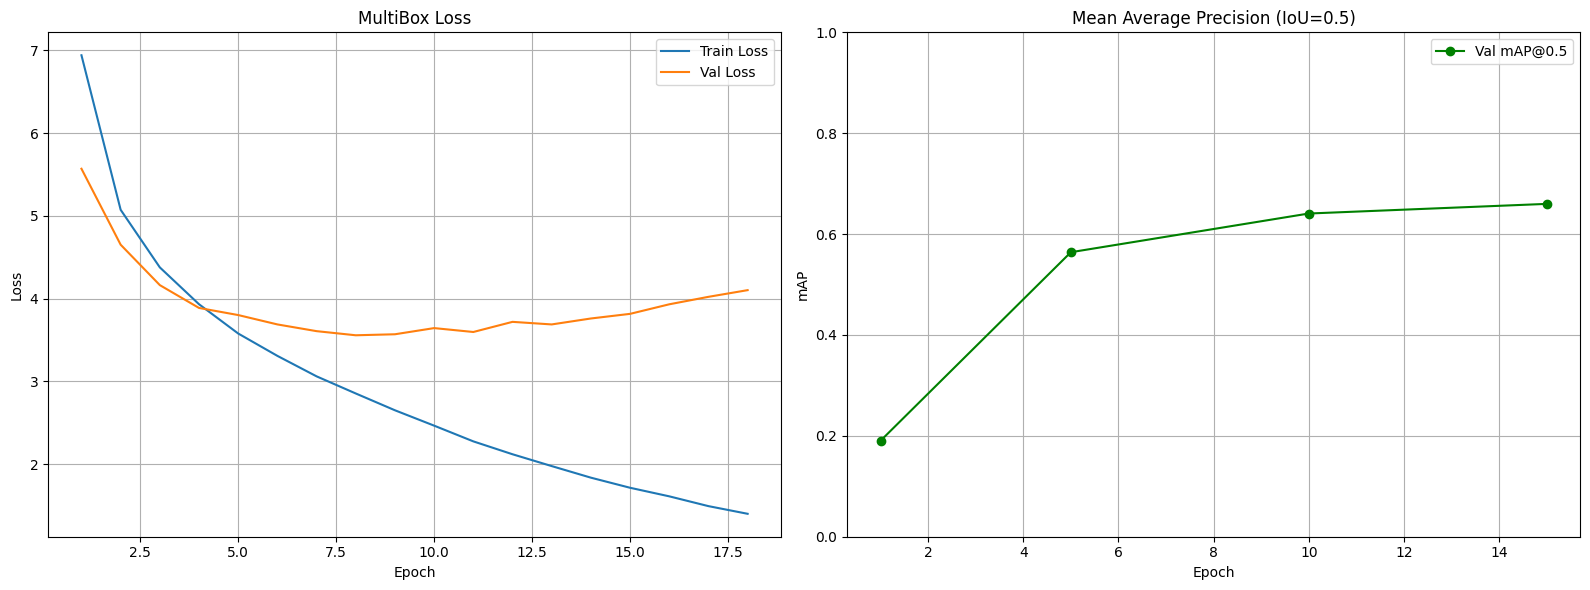

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(train_losses) + 1)

# Loss curves
axes[0].plot(epochs_range, train_losses, label="Train Loss")
axes[0].plot(epochs_range, val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("MultiBox Loss")
axes[0].legend()
axes[0].grid(True)

# mAP curve (only non-zero values)
map_epochs = [e for e, m in zip(epochs_range, val_maps) if m > 0]
map_values = [m for m in val_maps if m > 0]
axes[1].plot(map_epochs, map_values, "o-", label="Val mAP@0.5", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("Mean Average Precision (IoU=0.5)")
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


# 9. Evaluation on Validation Set

In [ ]:
# Compute final mAP on the validation set
val_map_final = compute_map(model, val_loader, priors_cxcy, NUM_CLASSES)
print(f"Val mAP@0.5: {val_map_final:.4f}")

# Per-class AP breakdown
print("\n--- Per-Class Results ---")
model.eval()

# Recompute per-class AP for detailed output
all_det_scores = {c: [] for c in range(1, NUM_CLASSES)}
all_det_is_tp = {c: [] for c in range(1, NUM_CLASSES)}
n_gt_per_class = {c: 0 for c in range(1, NUM_CLASSES)}

with torch.no_grad():
    for images, gt_boxes_list, gt_labels_list in val_loader:
        images = images.to(device)
        detections = detect_objects(
            model, images, priors_cxcy, conf_threshold=0.01, nms_threshold=NMS_THRESHOLD
        )

        for idx in range(len(detections)):
            det = detections[idx]
            gt_boxes = gt_boxes_list[idx].to(device)
            gt_labels = gt_labels_list[idx].to(device)

            for c in range(1, NUM_CLASSES):
                n_gt_per_class[c] += (gt_labels == c).sum().item()

            gt_matched = torch.zeros(gt_boxes.size(0), dtype=torch.bool, device=device)

            for det_idx in range(det["boxes"].size(0)):
                det_box = det["boxes"][det_idx].unsqueeze(0)
                det_label = det["labels"][det_idx].item()
                det_score = det["scores"][det_idx].item()

                class_mask = gt_labels == det_label
                if class_mask.sum() == 0:
                    all_det_scores[det_label].append(det_score)
                    all_det_is_tp[det_label].append(False)
                    continue

                gt_class_boxes = gt_boxes[class_mask]
                gt_class_indices = torch.where(class_mask)[0]
                iou = compute_iou(det_box, gt_class_boxes).squeeze(0)
                best_iou, best_gt_local_idx = iou.max(dim=0)
                best_gt_global_idx = gt_class_indices[best_gt_local_idx]

                if best_iou >= 0.5 and not gt_matched[best_gt_global_idx]:
                    all_det_scores[det_label].append(det_score)
                    all_det_is_tp[det_label].append(True)
                    gt_matched[best_gt_global_idx] = True
                else:
                    all_det_scores[det_label].append(det_score)
                    all_det_is_tp[det_label].append(False)

for c in range(1, NUM_CLASSES):
    n_gt = n_gt_per_class[c]
    if n_gt == 0:
        print(f"  {CLASS_NAMES[c]:12s}: no GT objects")
        continue

    scores = np.array(all_det_scores[c])
    is_tp = np.array(all_det_is_tp[c], dtype=bool)
    sort_idx = np.argsort(-scores)
    is_tp = is_tp[sort_idx]

    tp_cumsum = np.cumsum(is_tp)
    fp_cumsum = np.cumsum(~is_tp)
    recall = tp_cumsum / n_gt
    precision = tp_cumsum / (tp_cumsum + fp_cumsum)

    ap = 0.0
    for t in np.arange(0.0, 1.1, 0.1):
        prec_at_recall = precision[recall >= t]
        if len(prec_at_recall) > 0:
            ap += prec_at_recall.max()
    ap /= 11.0

    print(f"  {CLASS_NAMES[c]:12s}: AP = {ap:.4f} ({n_gt} GT objects)")


Val mAP@0.5: 0.6385

--- Per-Class Results ---
  aeroplane   : AP = 0.7128 (285 GT objects)
  bicycle     : AP = 0.7349 (337 GT objects)
  bird        : AP = 0.6342 (459 GT objects)
  boat        : AP = 0.4906 (263 GT objects)
  bottle      : AP = 0.3355 (469 GT objects)
  bus         : AP = 0.7152 (213 GT objects)
  car         : AP = 0.7877 (1201 GT objects)
  cat         : AP = 0.8023 (358 GT objects)
  chair       : AP = 0.3983 (756 GT objects)
  cow         : AP = 0.6023 (244 GT objects)
  diningtable : AP = 0.6016 (206 GT objects)
  dog         : AP = 0.7499 (489 GT objects)
  horse       : AP = 0.7623 (348 GT objects)
  motorbike   : AP = 0.7164 (325 GT objects)
  person      : AP = 0.7102 (4528 GT objects)
  pottedplant : AP = 0.3330 (480 GT objects)
  sheep       : AP = 0.6550 (242 GT objects)
  sofa        : AP = 0.6416 (239 GT objects)
  train       : AP = 0.7247 (282 GT objects)
  tvmonitor   : AP = 0.6621 (308 GT objects)


# 10. Visualization of Detections
Run detections on sample test images and visualize the predicted bounding boxes with class labels and confidence scores.

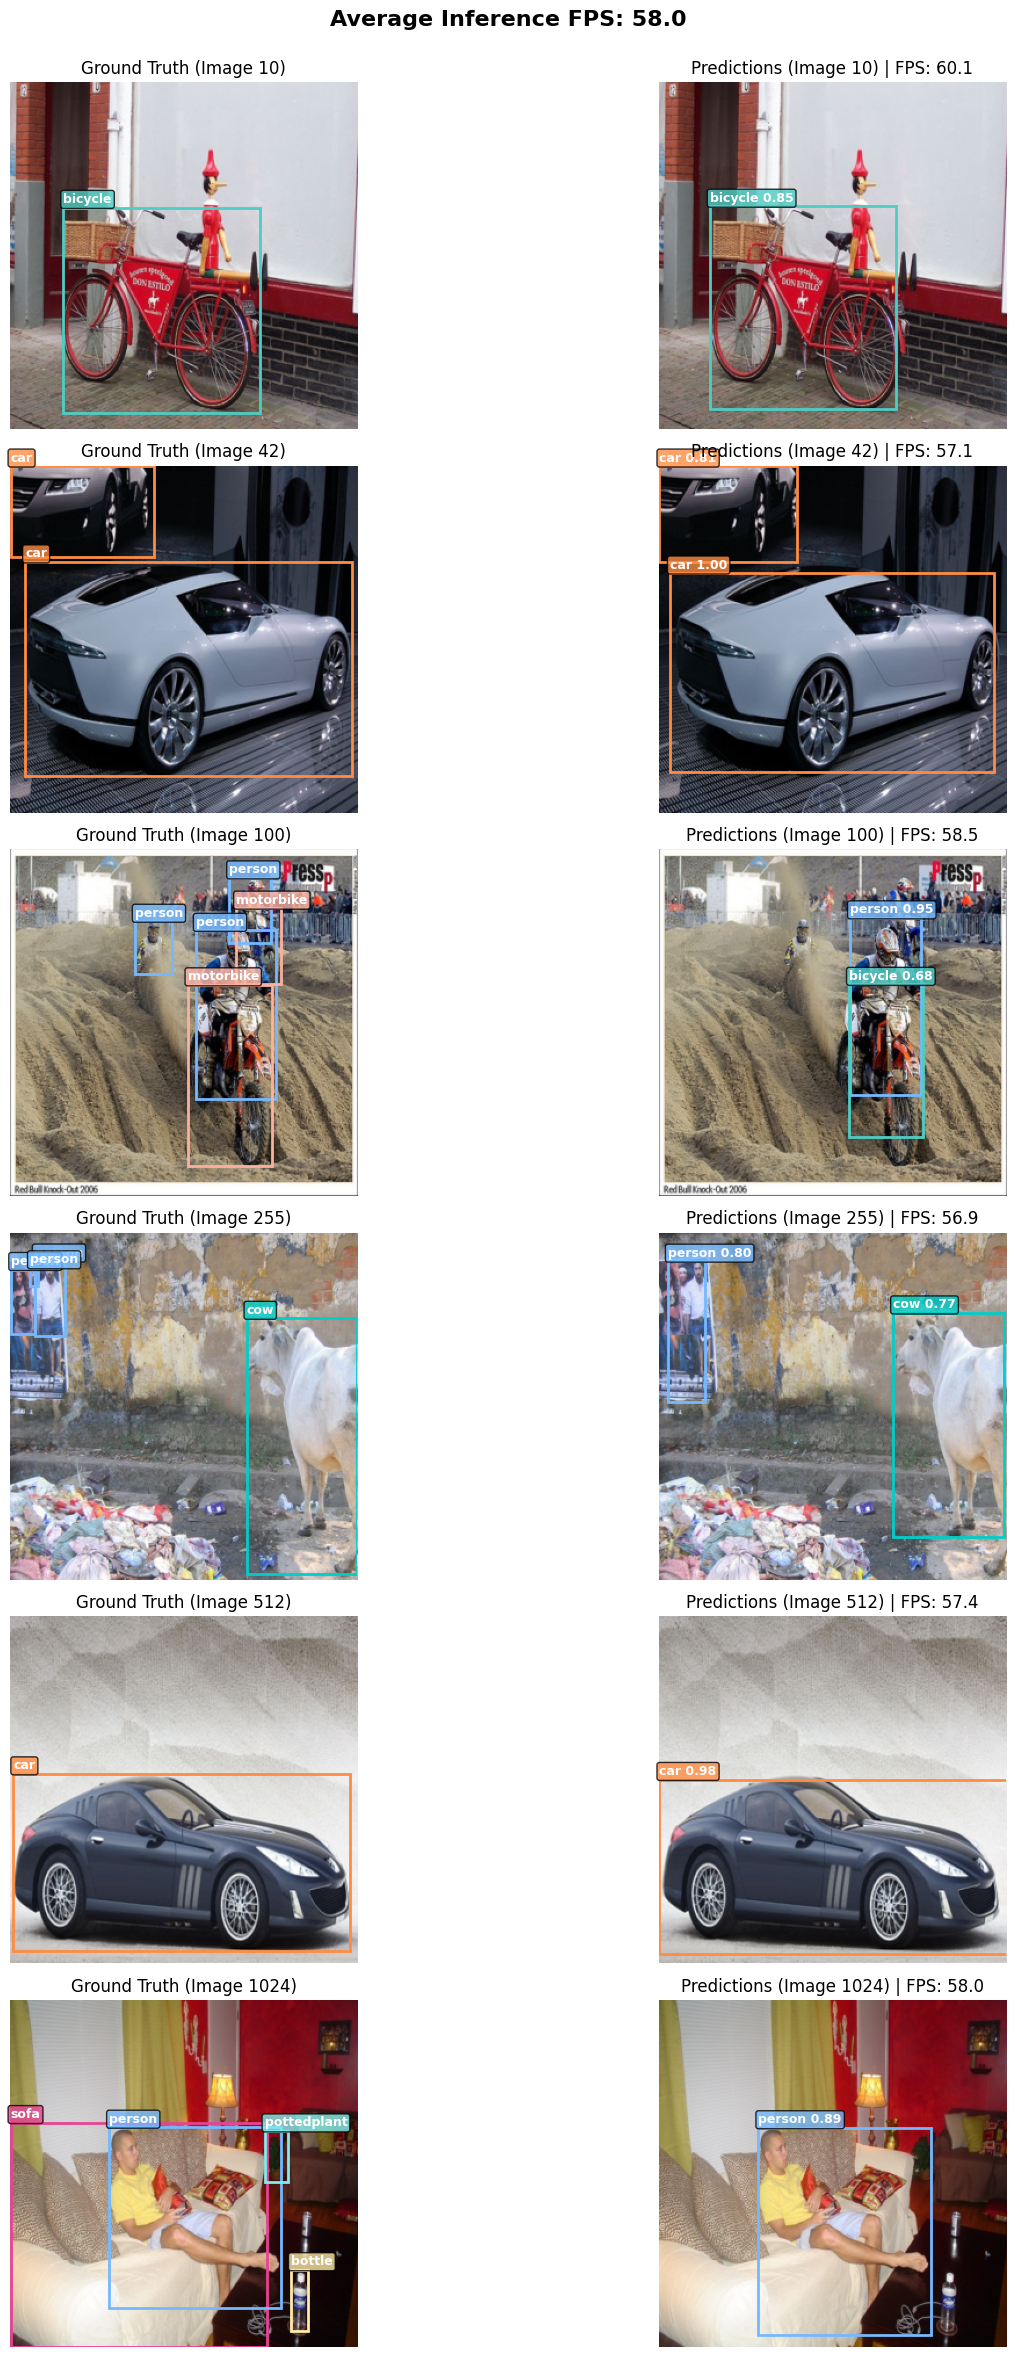

In [ ]:
import time

# Color palette for each class (distinct colors for visualization)
CLASS_COLORS = [
    "black",  # 0:  background (not used)
    "#FF6B6B",  # 1:  aeroplane    (red)
    "#4ECDC4",  # 2:  bicycle      (teal)
    "#45B7D1",  # 3:  bird         (blue)
    "#96CEB4",  # 4:  boat         (green)
    "#FFEAA7",  # 5:  bottle       (yellow)
    "#DDA0DD",  # 6:  bus          (plum)
    "#FF8C42",  # 7:  car          (orange)
    "#A29BFE",  # 8:  cat          (lavender)
    "#FD79A8",  # 9:  chair        (pink)
    "#00CEC9",  # 10: cow          (cyan)
    "#E17055",  # 11: diningtable  (burnt orange)
    "#6C5CE7",  # 12: dog          (purple)
    "#55EFC4",  # 13: horse        (mint)
    "#FAB1A0",  # 14: motorbike    (salmon)
    "#74B9FF",  # 15: person       (sky blue)
    "#81ECEC",  # 16: pottedplant  (aqua)
    "#FDCB6E",  # 17: sheep        (gold)
    "#E84393",  # 18: sofa         (magenta)
    "#00B894",  # 19: train        (emerald)
    "#636E72",  # 20: tvmonitor    (grey)
]


# ImageNet denormalization for visualization
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)


def visualize_detections(
    model, dataset, priors_cxcy, n_samples=8, conf_threshold=0.3, fixed_indices=None
):
    """Visualize object detections on sample images and calculate FPS.

    Shows side-by-side: (left) ground-truth boxes, (right) predicted boxes.
    """
    model.eval()

    # 1. Use fixed indices if provided to ensure the same images are used across different models
    if fixed_indices is not None:
        indices = fixed_indices[:n_samples]
    else:
        indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    fig, axes = plt.subplots(len(indices), 2, figsize=(16, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, 2)

    total_fps = 0.0

    for row, idx in enumerate(indices):
        image, gt_boxes, gt_labels = dataset[idx]

        image_batch = image.unsqueeze(0).to(device)

        # 2. FPS Calculation
        # Synchronize before starting the timer to ensure accurate measurement on GPU
        if device.type == "cuda":
            torch.cuda.synchronize()
        start_time = time.time()

        # Disable gradient calculation for faster inference
        with torch.no_grad():
            detections = detect_objects(
                model,
                image_batch,
                priors_cxcy,
                conf_threshold=conf_threshold,
                nms_threshold=NMS_THRESHOLD,
            )[0]

        # Synchronize again before stopping the timer
        if device.type == "cuda":
            torch.cuda.synchronize()
        end_time = time.time()

        # Calculate FPS for the current image
        inference_time = end_time - start_time
        fps = 1.0 / inference_time if inference_time > 0 else 0.0
        total_fps += fps

        # Denormalize image for display
        img_display = denormalize(image).permute(1, 2, 0).numpy()

        # --- Ground Truth (left column) ---
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"Ground Truth (Image {idx})", fontsize=12)
        axes[row, 0].axis("off")

        for j in range(gt_boxes.size(0)):
            box = gt_boxes[j].numpy() * IMG_SIZE  # Scale to pixel coords
            label = gt_labels[j].item()
            color = CLASS_COLORS[label]
            rect = patches.Rectangle(
                (box[0], box[1]),
                box[2] - box[0],
                box[3] - box[1],
                linewidth=2,
                edgecolor=color,
                facecolor="none",
            )
            axes[row, 0].add_patch(rect)
            axes[row, 0].text(
                box[0],
                box[1] - 4,
                CLASS_NAMES[label],
                color="white",
                fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8),
            )

        # --- Predictions (right column) ---
        axes[row, 1].imshow(img_display)
        # Display FPS in the title of the prediction
        axes[row, 1].set_title(
            f"Predictions (Image {idx}) | FPS: {fps:.1f}", fontsize=12
        )
        axes[row, 1].axis("off")

        det_boxes = detections["boxes"].cpu()
        det_labels = detections["labels"].cpu()
        det_scores = detections["scores"].cpu()

        for j in range(det_boxes.size(0)):
            box = det_boxes[j].numpy() * IMG_SIZE
            label = det_labels[j].item()
            score = det_scores[j].item()
            color = CLASS_COLORS[label]
            rect = patches.Rectangle(
                (box[0], box[1]),
                box[2] - box[0],
                box[3] - box[1],
                linewidth=2,
                edgecolor=color,
                facecolor="none",
            )
            axes[row, 1].add_patch(rect)
            axes[row, 1].text(
                box[0],
                box[1] - 4,
                f"{CLASS_NAMES[label]} {score:.2f}",
                color="white",
                fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8),
            )

    # Display the average FPS over all sample images
    avg_fps = total_fps / len(indices)
    plt.suptitle(
        f"Average Inference FPS: {avg_fps:.1f}", fontsize=16, fontweight="bold"
    )
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Adjust layout to fit the suptitle
    plt.show()


fixed_indices = [10, 42, 100, 255, 512, 1024]
visualize_detections(
    model,
    val_dataset,
    priors_cxcy,
    n_samples=6,
    fixed_indices=fixed_indices,
    conf_threshold=CONF_THRESHOLD,
)
